In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
# Directory = r'D:\Ring_MIT_Sid_chip\scripts\RingMod_Squeezing'
# os.chdir(Directory)
pwd = os.getcwd()

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path

REPO_ROOT = Path(pwd).resolve().parents[1]
WORKDIR = REPO_ROOT / "scripts" / "RingMod_Squeezing"
os.chdir(WORKDIR)
print("Current working directory:", os.getcwd())

# --- Save directory ---
data_save_dir = REPO_ROOT / "results_data" / "Data_RingMod_Squeezing"
data_save_dir.mkdir(parents=True, exist_ok=True)
print("Data will be saved to:", data_save_dir)

assert WORKDIR.exists(), "WORKDIR does not exist"
assert data_save_dir.exists(), "Data save dir not created"

Current working directory: D:\Ring_MIT_Sid_chip\scripts\RingMod_Squeezing
Data will be saved to: D:\Ring_MIT_Sid_chip\results_data\Data_RingMod_Squeezing


In [2]:
neff = 1.5277
L = 2 * np.pi * 60E-6 
lambda0 = 1550E-9

M = int(neff * L / lambda0)
print("M =", M)

M = 371


In [3]:
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")
                
LumFileName = 'RingMOD_Squeez.lms' # save .lms file
f.save(LumFileName)
# Clear existing elements
f.switchtolayout()
f.selectall()
f.delete()
f.switchtolayout()

Starting new Lumerical MODE session...


C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [4]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
LambdaStart    = 1525E-9
LambdaStop     = 1575E-9

Width          = 1500E-9
Height         = 200E-9
Radius         = 60E-6
Gap            = 600E-9
Length         = 4 * Radius
YLength        = Radius
Material       = "Si3N4 (Silicon Nitride) - Luke"
CouplingLength = 0.0E-6
Index          = 2; #optional
decay_time     = 1E-7

BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 1200E-12
# FrequencyPoints    = 2*10000; #for monitors 
FrequencyPoints    = round(2000 * (LambdaStop - LambdaStart) * 1E9)
print(f"Frequency Points: {FrequencyPoints}")


Frequency Points: 100000


Mode numbers: [371]
Relative μ: [0]
Amplitudes (nm): [0.]
Minimum radius: 1.50 µm
Maximum radius: 1.50 µm
Ring Area: 565.49 µm²
Modulated Ring Area: 565.49 µm²
Area Difference due to modulation: 0.00 µm²


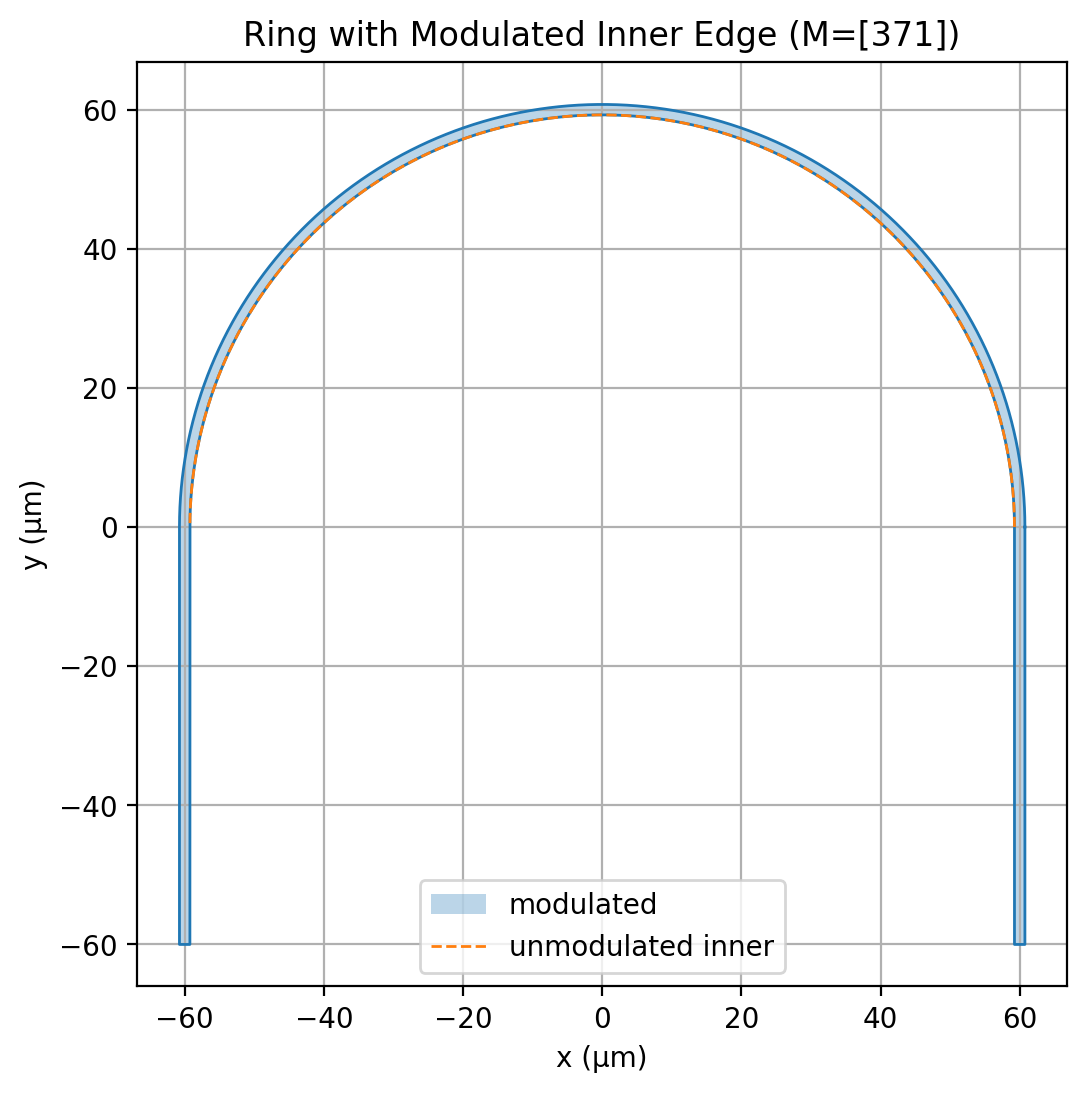

Figure saved as 'modulated_ring_zoom.png'. You can download it from the notebook file browser.


In [5]:
# --- Mode number tracking ---------------

M_ref = 371 # Mode numbers (using 300 as reference μ=0)
# M     = np.array(np.linspace(370,373,2))
M = [371]  # Mode numbers to be modulated
mu    = np.array(M) - M_ref  # Relative mode numbers: [1, 2, 5, 10, 20]
print(f"Mode numbers: {M}")
print(f"Relative μ: {mu}")

# --- Amplitude of modulation ---------------

A_max = 0E-9
# A = A_max*(abs(mu)/np.max(mu))**2  # Amplitude of modulation
A = A_max*np.ones_like(mu)     # Amplitude of modulation
print(f"Amplitudes (nm): {A*1e9}")
Npoints = max(5000, 300*M_ref)  # Number of points for smoothness

#--- Modulated Ring Generation --------------

def generate_half_ring_with_length(Radius=4e-6,
                                    width=700e-9,
                                    A=300e-9,
                                    M=50,
                                    Npoints=1000,length_extra=Length):
    theta         = np.linspace(0, np.pi, Npoints)
    R_inner_base  = Radius - width/2
    R_outer_base  = Radius + width/2

    # ensure A_list, M_list
    A_list = np.atleast_1d(A)
    M_list = np.atleast_1d(M)

    # sum of cosines
    modulation = np.zeros_like(theta)
    for i, (Ai, Mi) in enumerate(zip(A_list, M_list)):
        
        if Mi == 0:
            # No modulation for M=0
            modulation += Ai
        else:
            # Normalized modulation
            # modulation += Ai * (np.cos(2*Mi * theta + (2*np.pi/ (i+1))))
            modulation += Ai * np.cos(2*Mi * theta + (2*np.pi/len(M_list))*i)

    R_inner       = R_inner_base - modulation
    R_outer_const = R_outer_base
    
    min_radius = np.min(R_outer_const-R_inner)
    print(f"Minimum radius: {min_radius*1e6:.2f} µm")
    
    max_radius = np.max(R_outer_const-R_inner)
    print(f"Maximum radius: {max_radius*1e6:.2f} µm")

    RingArea = np.pi * (R_outer_const**2 - R_inner_base**2)
    print(f"Ring Area: {RingArea*1e12:.2f} µm²")
    
    ModRingArea = np.pi * (R_outer_const**2 - np.mean(R_inner**2))
    print(f"Modulated Ring Area: {ModRingArea*1e12:.2f} µm²")
    
    AreaDiff = ModRingArea - RingArea
    print(f"Area Difference due to modulation: {AreaDiff*1e12:.2f} µm²")
    L_strain = length_extra
    # Outer arc θ=0→π (not reversed)
    x_outer = R_outer_base * np.cos(theta)
    y_outer = R_outer_base * np.sin(theta)

    # Left wg: down and back up
    left_wg_x = np.array([-R_outer_base, -R_outer_base, -R_inner_base, -R_inner_base])
    left_wg_y = np.array([0, -L_strain, -L_strain, 0])

    # Inner arc θ=π→0 (reversed)
    x_inner = R_inner * np.cos(theta[::-1])  
    y_inner = R_inner * np.sin(theta[::-1])

    # Right wg: down and back up
    right_wg_x = np.array([R_inner_base, R_inner_base, R_outer_base, R_outer_base])
    right_wg_y = np.array([0, -L_strain, -L_strain, 0])

    x_poly = np.concatenate([x_outer, left_wg_x, x_inner, right_wg_x])
    y_poly = np.concatenate([y_outer, left_wg_y, y_inner, right_wg_y])

    return x_poly, y_poly

x_poly, y_poly = generate_half_ring_with_length(Radius=Radius ,
                                            width=Width, A = A, M=M, Npoints=Npoints, length_extra=YLength)
# compute unmodulated inner ring
theta_base   = np.linspace(0, np.pi, Npoints)
R_inner_base = Radius - Width/2
x_base       = R_inner_base * np.cos(theta_base)
y_base       = R_inner_base * np.sin(theta_base)

# visualize
plt.figure(figsize=(6,6))
plt.fill(x_poly*1e6, y_poly*1e6, alpha=0.3, label='modulated')
plt.plot(x_poly*1e6, y_poly*1e6, '-', linewidth=1)
plt.plot(x_base*1e6, y_base*1e6, '--', linewidth=1, label='unmodulated inner')
plt.axis('equal')
plt.gcf().set_dpi(200)
plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.title(f'Ring with Modulated Inner Edge (M={M})')
plt.legend()
plt.grid()

# Save figure as high-res PNG for zooming in
plt.savefig("modulated_ring_zoom.png", dpi=600, bbox_inches='tight')
plt.show()

print("Figure saved as 'modulated_ring_zoom.png'. You can download it from the notebook file browser.")

In [6]:
#------------------------------------------------------------
# STRUCTURE GROUP : Ring 
#------------------------------------------------------------

group_name = "Ring Resonator Group"
f.addstructuregroup()
f.set("name", group_name)
f.set("construction group", 1)
f.set("x",0)
f.set("y",0)
f.set("z",0)

# ADD USER PROPERTIES (keep original ones only)
f.adduserprop("Width",          2, Width)
f.adduserprop("Height",         2, Height)
f.adduserprop("Radius",         2, Radius)
f.adduserprop("Gap",            2, Gap)
f.adduserprop("Length",         2, Length)
f.adduserprop("Material",       5, Material)
f.adduserprop("Index",          0, Index)
f.adduserprop("CouplingLength", 2, CouplingLength)

# Convert vertices to Lumerical matrix format
vertices_str = "["
for i in range(len(x_poly)):
    vertices_str += f"{x_poly[i]}, {y_poly[i]};"
vertices_str = vertices_str.rstrip(';') + "]"

#------------------------------------------------------------
# GEOMETRY SETUP SCRIPT
#------------------------------------------------------------

setup_script = f"""
# Base waveguides
addrect;
set('name','WG1');
set('x', 0);
set('x span', Length);
set('y span', Width);
set('y', Radius + Gap + Width);
# copy(0, -2 * (Radius + Gap + Width), 0);

# Modulated Ring using polygon vertices
addpoly;
set('name', 'modulated_ring');
set('vertices', {vertices_str});

# Assign materials & finalize structure
selectall;
set('material', Material);
if (Material == '<Object defined dielectric>') {{
    set('index', Index);
}}
set('z min', 0);
set('z max', Height);
"""

f.set("script", setup_script)

#------------------------------------------------------------
# EigenMode Solver 
#------------------------------------------------------------

# f.addfde()
# f.set("x", Radius+CouplingLength/2-Width/2)  # Aligned with the right ring
# f.set("x span", 2 * Width)
# f.set("y", 0)  # Centered in Y
# f.set("z", Height / 2)  # Centered in Z
# f.set("y span", 2 * Width)
# f.set("solver type", "2D Y Normal")
# f.set("wavelength", (LambdaStart + LambdaStop) / 2)
# f.set("background material", BackgroundMaterial)

In [7]:
xc = 0.5 * (np.max(x_poly) + np.min(x_poly)) 
yc = 0.5 * (np.max(y_poly) + np.min(y_poly))-YLength
print(f"Center of modulated ring: xc={xc*1e6:.2f} µm, yc={yc*1e6:.2f} µm")

# varFDTS bounds
x0 = Radius - CouplingLength/2
y0 = yc+YLength/2

margin = 2 * LambdaStop

# FDTD bounds (GLOBAL coordinates)
y_fdtd_min  = -4 * margin
y_fdtd_max  = Radius + Gap + Width + margin

x_fdtd_span = 2*(Radius+CouplingLength+margin)

print(f"Dimension summary (µm):")
print(f"x0: {x0*1e6:.2f}, y0: {y0*1e6:.2f}")
print(f"y_fdtd_min: {y_fdtd_min*1e6:.22}, y_fdtd_max: {y_fdtd_max*1e6:.2f}")

test_points = np.zeros((2, 4))

test_points[0,0] = x0
test_points[1,0] = y0

test_points[0,1] = -x0
test_points[1,1] = y0

test_points[0,2] = -x0
test_points[1,2] = y0+0.1E-6

test_points[0,3] = x0
test_points[1,3] = y0+0.1E-6

print("Test point (µm):", test_points*1e6)

## Monitor Positions (relative to FDTD origin) ##
xpos_cross = x0 
ypos_cross = -margin/2

xpos_refelct2 = -x0
ypos_refelct2 = ypos_cross

xpos_through = x0
ypos_through = Radius + Gap + Width

xpos_reflect1 = -x0
ypos_reflect1 = ypos_through

ymax_field_monitor = Radius+Gap+Width+margin/2
ymin_field_moniotr = ymax_field_monitor - 8*Width

# print("Monitor Positions (µm):")
# print(f"Cross: ({xpos_cross*1e6:.2f}, {ypos_cross*1e6:.2f})")
# print(f"Reflect 2: ({xpos_refelct2*1e6:.2f}, {ypos_refelct2*1e6:.2f})")
# print(f"Through: ({xpos_through*1e6:.2f}, {ypos_through*1e6:.2f})")
# print(f"Reflect 1: ({xpos_reflect1*1e6:.2f}, {ypos_reflect1*1e6:.2f})")   
# print(f"Field monitor ymax, ymin: ({ymax_field_monitor*1e6:.2f}, {ymin_field_moniotr*1e6:.2f})")  
#------------------------------------------------------------
# VarFDTD  (RING CENTERED AT x=0, y=0 — CORRECT SETUP)
#------------------------------------------------------------

# Add VarFDTD
f.addvarfdtd()
f.set("x", xc)
f.set("y", yc)
f.set("x0", x0)
f.set("y0", y0)
f.set("x span", x_fdtd_span)
f.set("y min", y_fdtd_min)
f.set("y max", y_fdtd_max)
f.set("z", Height / 2)
f.set("z span", 8 * Height)

# --- Materials & physics ---
f.set("background material", BackgroundMaterial)
f.set("set simulation bandwidth", 1)
f.set("bandwidth", "broadband")
f.set("simulation wavelength min", LambdaStart)
f.set("simulation wavelength max", LambdaStop)
f.set("simulation time", SimulationTime)
f.set("auto shutoff min", decay_time)

# --- Boundary conditions ---
f.set("x min bc", "PML")
f.set("x max bc", "PML")
f.set("y min bc", "PML")
f.set("y max bc", "PML")
f.set("z min bc", "PML")
f.set("z max bc", "PML")
f.set("test points", test_points)

#------------------------------------------------------------
# Source
#------------------------------------------------------------

f.addmodesource()
f.set("name", "ModeSource")
f.set("x", xpos_reflect1 + 1.25*LambdaStop)
f.set("y", ypos_reflect1)
f.set("y span", 2 * Width)
f.set("use relative coordinates", 1)
f.set("injection axis", "x-axis")
f.set("direction", "Forward")
f.set("amplitude", 1.0)
f.set("phase", 0)
f.set("mode selection", "fundamental mode")
f.set("set wavelength", 1)
f.set("wavelength start", LambdaStart)
f.set("wavelength stop", LambdaStop)

# f.addplane()
# f.set("name", "PlaneWaveSource")
# f.set("injection axis", "x-axis")
# f.set("x", -Radius-CouplingLength/2)
# f.set("y", Radius + Gap + Width/2)
# f.set("y span", Width)
# f.set("use relative coordinates", 1)
# f.set("direction", "Forward")
# f.set("amplitude", 1.0)
# f.set("phase", 0)
# f.set("set wavelength", 1)
# f.set("wavelength start", LambdaStart)
# f.set("wavelength stop", LambdaStop)

#------------------------------------------------------------
# Monitors 
#------------------------------------------------------------

# THROUGH PORT (3)
f.adddftmonitor()
f.set("name", "Port3")
f.set("monitor type", "Linear Y")
f.set("x", xpos_through)
f.set("y", ypos_through)
f.set("y span", 2 * Width)
f.set("z", Height / 2)  # Centered in Z
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

# CROSS PORT (4)
f.adddftmonitor()
f.set("name", "Port4")
f.set("monitor type", "Linear X")
f.set("x", xpos_cross)
f.set("y", ypos_cross)
f.set("x span", 2 * Width)
f.set("z", Height / 2)  # Centered in Z
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

# REFLECTION PORT (2)
f.adddftmonitor()
f.set("name", "Port2")
f.set("monitor type", "Linear X")
f.set("x", xpos_refelct2)
f.set("y", ypos_refelct2)
f.set("x span", 2 * Width)
f.set("z", Height / 2)  # Centered in Z
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)

# REFLECTION PORT (1)
f.adddftmonitor()
f.set("name", "Port1")
f.set("monitor type", "Linear Y")
f.set("x", xpos_reflect1)
f.set("y", ypos_reflect1)
f.set("y span", 2 * Width)
f.set("z", Height / 2)  # Centered in Z
f.set("override global monitor settings", 1)
f.set("use source limits", 1)
f.set("frequency points", FrequencyPoints)


# Field Monitor PORT
f.adddftmonitor()
f.set("name", "Field Monitor")
f.set("monitor type", "2D Z-normal")
f.set("x", 0)                    # Centered in X
f.set("y", Radius+Gap/2)          # Centered in Y
f.set("x span", 2*(Radius+CouplingLength+margin*0.25))    # Cover full structure    
f.set("y max", ymax_field_monitor)  # Cover full waveguide & ring
f.set("y min", ymin_field_moniotr)
f.set("z", Height / 2)  # Centered in Z
f.set("override global monitor settings", 1)
f.set('use wavelength spacing',1)
f.set('wavelength center', 1550E-9)  # Center wavelength
f.set('wavelength span', 5E-9) 
f.set("frequency points", 5)

Center of modulated ring: xc=0.00 µm, yc=-59.63 µm
Dimension summary (µm):
x0: 60.00, y0: -29.63
y_fdtd_min: -12.59999999999999964473, y_fdtd_max: 65.25
Test point (µm): [[ 60.    -60.    -60.     60.   ]
 [-29.625 -29.625 -29.525 -29.525]]


In [ ]:
#------------------------------------------------------------
# Run
#------------------------------------------------------------
f.run()

index at 1550 = 49193, wavelenth at idx_1550 = 1550.00
Tx cross at 1550 = 0.10170800763724135, Tx through at 1550 = 0.8814646591888657
gap=600.00nm | η=10.34% | Loss=0.07dB


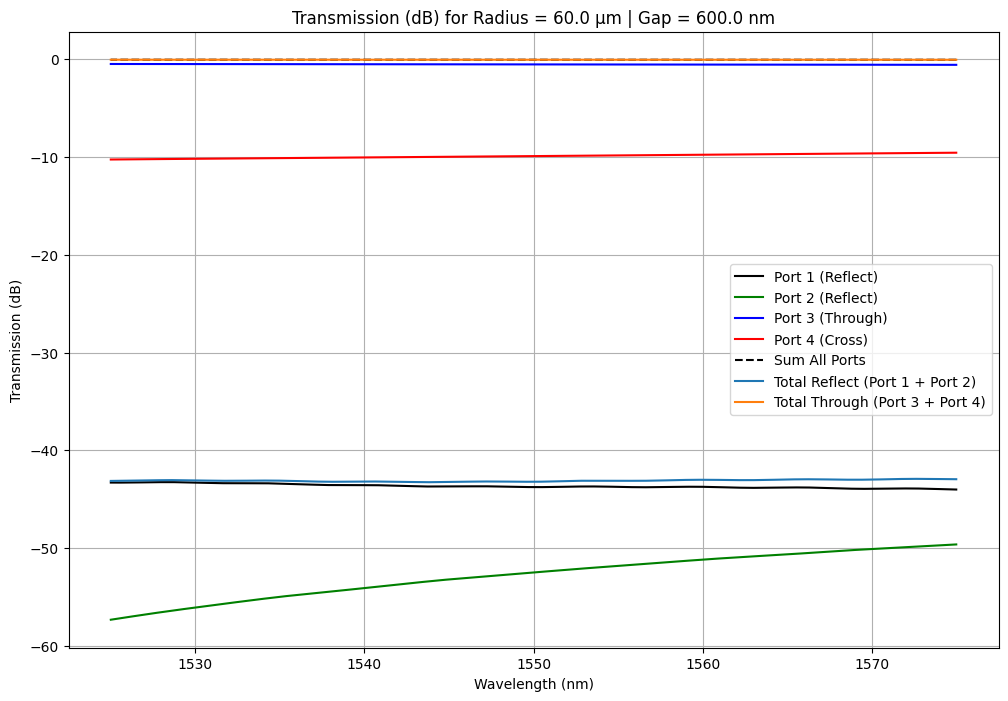

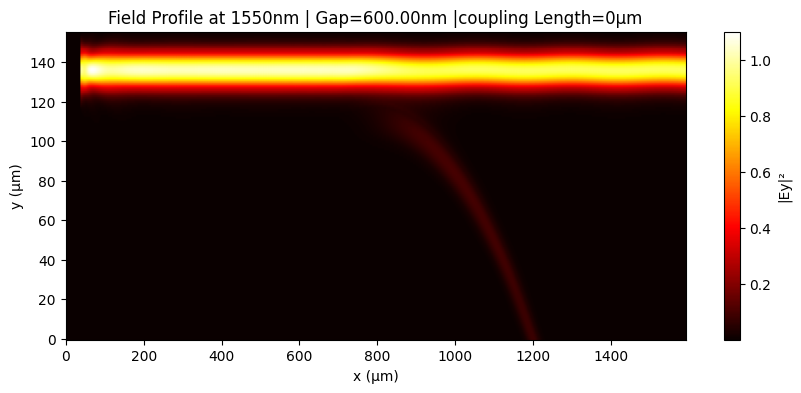

In [ ]:
#------------------------------------------------------------
# Save Data
#------------------------------------------------------------
T_Port1 = f.getresult("Port1", "T")
T_port2 = f.getresult("Port2", "T")
T_port3 = f.getresult("Port3", "T")
T_port4 = f.getresult("Port4", "T")

Tx_Reflect_1 = -T_Port1["T"].flatten()
Tx_Reflect_2 = -T_port2["T"].flatten()
Tx_Through = T_port3["T"].flatten()
Tx_Cross = -T_port4["T"].flatten()
Wavelenghth = T_port2["lambda"].flatten()

Tx_total_out = Tx_Through + Tx_Cross 
Tx_total_reflect = Tx_Reflect_2 + Tx_Reflect_1

# Matric at 1550 nm ----------------------------------
idx_1550 = np.argmin(np.abs(Wavelenghth - 1550e-9))
print(f"index at 1550 = {idx_1550}, wavelenth at idx_1550 = {Wavelenghth[idx_1550]*1E9:.2f}")

print(f"Tx cross at 1550 = {Tx_Cross[idx_1550]}, Tx through at 1550 = {Tx_Through[idx_1550]}")
eta_1550 = Tx_Cross[idx_1550] / (Tx_Cross[idx_1550] + Tx_Through[idx_1550])
loss_dB_1550 = -10 * np.log10(Tx_total_out[idx_1550])


# 3dB bandwidth
eta_array = Tx_Cross / (Tx_total_out)
eta_variation = eta_array.max() - eta_array.min()

print(f"gap={Gap*1e9:.2f}nm | η={eta_1550:.2%} | Loss={loss_dB_1550:.2f}dB")

# -----------------------
plt.figure(figsize=(12,8))
plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_1)),'k', label='Port 1 (Reflect)')
plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_2)),'g', label='Port 2 (Reflect)')
plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Through)),'b', label='Port 3 (Through)')
plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Cross)),'r', label='Port 4 (Cross)')
plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_1 + Tx_Reflect_2 + Tx_Through + Tx_Cross)), label='Sum All Ports', linestyle='--', color='black')
plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Reflect_2 + Tx_Reflect_1)), label='Total Reflect (Port 1 + Port 2)')
plt.plot(Wavelenghth*1E9, 10*np.log10(np.abs(Tx_Through + Tx_Cross)), label='Total Through (Port 3 + Port 4)')
plt.title(f'Transmission (dB) for Radius = {Radius*1E6} µm | Gap = {Gap*1E9} nm')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission (dB)')
plt.legend()
plt.grid()
plt.show()

# field plot

E_field = f.getresult("Field Monitor", "E")
idx_field_1550 = np.argmin(np.abs(E_field['lambda'].flatten() - 1550e-9))

plt.figure(figsize=(10,4))
x = E_field['x'].flatten() * 1e6  # µm
y = E_field['y'].flatten() * 1e6

plt.imshow(np.abs(E_field['E'][:,:,0,idx_field_1550,1]).T**2, 
        aspect='auto', cmap='hot', origin='lower',) # type: ignore
plt.xlabel('x (µm)')
plt.ylabel('y (µm)')
plt.colorbar(label='|Ey|²')
plt.title(f'Field Profile at 1550nm | Gap={Gap*1e9:.2f}nm |coupling Length={CouplingLength*1e6:.0f}µm')
plt.show()


In [ ]:
# # --- Modulation summary ---
# M_min, M_max = int(M[0]), int(M[-1])
# Nmodes = len(M)
# M_ref = int(M_ref)

# # --- Header (parse-friendly) ---
# header = f"""Gap_nm={Gap*1e9:.2f}
# Width_nm={Width*1e9:.2f}
# Height_nm={Height*1e9:.2f}
# CouplingLength_um={CouplingLength*1e6:.2f}
# Radius_um={Radius*1e6:.2f}
# Material={Material}
# SimTime_ps={SimulationTime*1e12:.2f}
# FrequencyPoints={FrequencyPoints}
# LambdaStart_nm={LambdaStart*1e9:.2f}
# LambdaStop_nm={LambdaStop*1e9:.2f}

# M_ref={M_ref}
# M_min={M_min}
# M_max={M_max}
# Nmodes={Nmodes}
# A_max_nm={A_max*1e9:.4f}

# eta_drop_1550={eta_drop_1550:.6f}
# loss_drop_1550_dB={loss_drop_1550_dB:.4f}

# Wavelength_um\tTransmission_Through\tTransmission_Drop
# """

# # --- Filename ---
# filename = (
#     f"Data_{LumFileName.removesuffix('.lms')}_pwsource_"
#     f"Amax{A_max*1e9:.2f}nm_"
#     f"M{M_min}-{M_max}_Nm{Nmodes}_"
#     f"LambdaRange{int(LambdaStart*1e9)}-{int(LambdaStop*1e9)}nm_"
#     f"Gap{Gap*1e9:.0f}nm_Tx.txt"
# )

# filepath = data_save_dir / filename

# # --- Data ---
# data = np.column_stack((
#     Wavelenghth * 1e6,   # um intentional
#     Transmission_through,
#     Transmission_drop
# ))

# np.savetxt(
#     filepath,
#     data,
#     delimiter='\t',
#     header=header,
#     comments='# ',      # explicit, MATLAB/Python friendly
#     fmt='%.6e'
# )

# print(f"Data saved to {filepath}")
